# Exploring RNNs Through Stock Price Prediction
 #### A summative laboratory exercise in partial fulfillment of the requirements for the course CSELEC2C: Machine Learning
 Prepared by Raul Sebastien B. Baldemoro and Jan Vincent G. Elleazar <br> Department of Computer Science, College of Information and Computing Sciences, University of Santo Tomas, City of Manila, Philippines
 <br><br>
 ***

# Overview of the Summative Laboratory Exercise
This laboratory exercise focuses on applying the concepts discussed in CSELEC2C to real-world problems, using RNNs to analyze and predict stock price trends. **The objective is to gain hands-on experience with sequential data and understand the impact of hyperparameter tuning and architectural changes on the performance of RNN models.**

Unlike tasks aimed at achieving the highest possible accuracy, **this exercise emphasizes experimentation and critical thinking**. Exploring how changes in hyperparameters and network design affect the model's predictions is key to this assignment.

Our task is to create and train RNN-based models for stock price prediction using the provided dataset. The dataset contains sequential data representing historical stock prices, which we will use to predict future trends. Key objectives include: 

- Building an RNN model from scratch to handle sequential data;
- Experimenting with different hyperparameters (number of layers, hidden units, dropout rates, sequence lengths), and;
- Avoiding the use of pre-trained models or architectures (our work should be original).

The documentation for this exercise is included in the same directory. 

**Prerequisites:**
- TensorFlow
- Keras
- PyTorch
- NumPy
- Pandas
- Matplotlib
- Sci-Kit Learn
<br><br>
***

# Given Demonstration of the Summative Laboratory Exercise
This section presents the given demonstration of the exercise. This will be the foundation of our experimentation and exploration of the RNN architecture.
## Part 0: Import the Necessary Libraries

In [ ]:
# Importing the libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Part 1: Loading the Data

In [2]:
# First, we get the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN
2006-01-06,47.97,48.58,47.32,47.87,6154285,AMZN
2006-01-09,46.55,47.10,46.40,47.08,8945056,AMZN


## Part 2: Splitting the Data

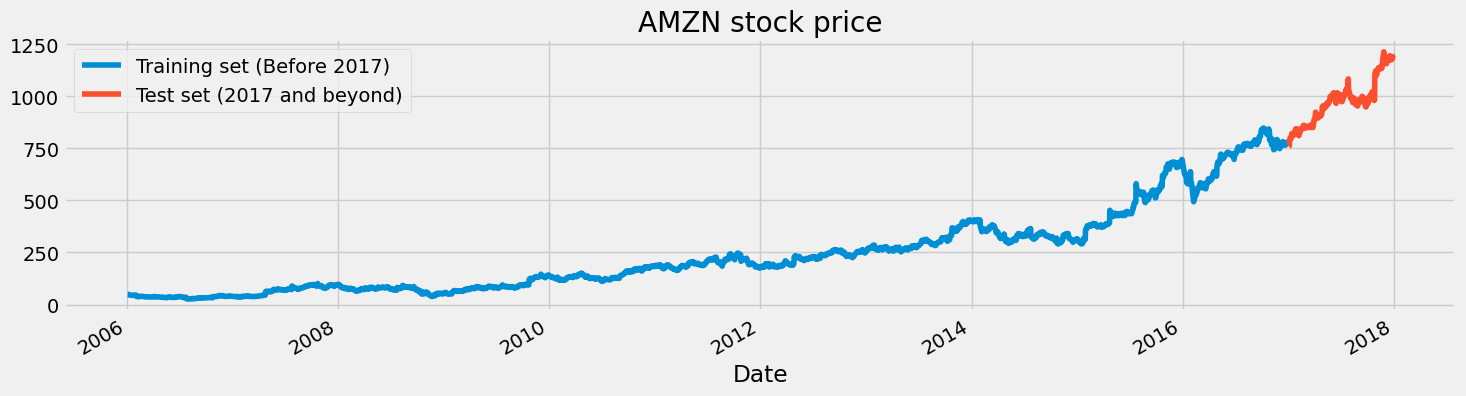

In [3]:
# Checking for missing values
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

# We have chosen 'High' attribute for prices. Let's see what it looks like
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('AMZN stock price')
plt.show()

## Part 3: Preprocessing the Data

In [4]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

## Part 4: Converting Inputs for RNN

In [5]:
# Since LSTMs store long term memory state, we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements
X_train = []
y_train = []
for i in range(60,2768):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshaping X_train for efficient modelling
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))
print(X_train.shape)

(2708, 60, 1)


## Part 5: RNN Model

In [6]:
# The LSTM architecture
regressor = Sequential()
# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
# Second LSTM layer
regressor.add(LSTM(units=5))
# The output layer
regressor.add(Dense(units=1))

# Compiling the RNN
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
# Fitting to the training set
regressor.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0782
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.4593e-04
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2075e-04
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.2924e-04
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1962e-04
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.9336e-04
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2398e-04
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.2386e-04
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9296e-04


## Part 6: Preparing Data for Testing

In [7]:
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

# Preparing X_test and predicting the prices

X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


## Part 7: Evaluation and Testing

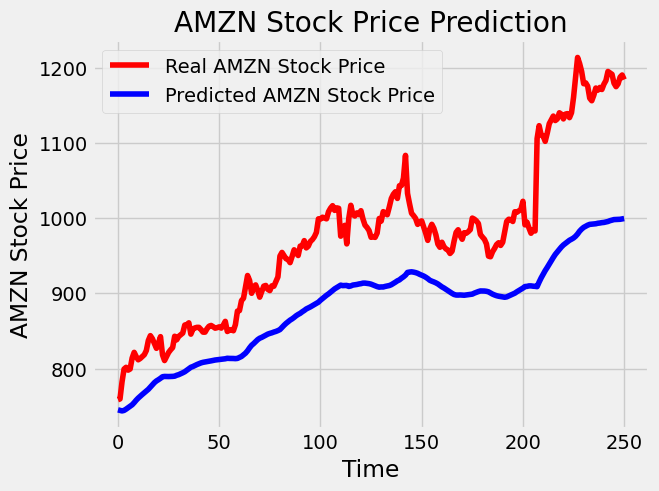

The root mean squared error is 104.30130631513545.


In [8]:
# Some functions to help out with
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Visualizing the results for LSTM
plot_predictions(test_set,predicted_stock_price)

# Evaluating our model
return_rmse(test_set,predicted_stock_price)

***
# Experimentation and Exploration
This section presents our experiments that we conducted to learn more about the RNN architectures and hyperparamteters. Furthermore, we will test diverse combinations in modifying the architecture and fine-tuning the hyperparameters of RNN to see the how those combinations affect the performance of RNN in predicting stock prices. Each experiments are listed below with its corresponding sub-experiments:
- Experiment #1: Other Data Preprocessing Methods
- Experiment #2: Adding Layers
- Experiment #3: Changing RNN
- Experiment #4: Changing Number of Units
- Experiment #5: Changing Learning Rate
- Experiment #6: Changing Sequence Length
- Experiment #7: Different Activation Functions
- Experiment #8: Adding Dropout to Input or Recurrent Layers
- Experiment #9: Different Optimizers
- Experiment #10: Lagged Features